# Image Data Generator
In the previous examples, we learned using existing image numpy arrays.

Here, we will see how to convert the actual raw images into numpy array so that we can process them.

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import requests
import os

#Source URL
drop_box_url="https://www.dropbox.com/s/h16vq9rab1itifs/CatDog.zip?dl=1"

#Download Zip file
zip_path='CatDog.zip'
with open(zip_path,'wb') as f:
  response=requests.get(drop_box_url)
  f.write(response.content)

#Unzip file
with zipfile.ZipFile(zip_path,'r') as f:
  f.extractall('image_data')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1.0/255,validation_split=0.2)

#Load training data
train_generator=datagen.flow_from_directory(
    directory='image_data',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator=datagen.flow_from_directory(
    directory='image_data',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 8023 images belonging to 2 classes.
Found 2005 images belonging to 2 classes.


<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>
(32, 150, 150, 3)
(32,)


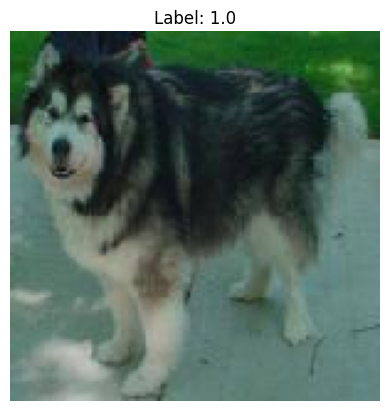

In [ ]:
# show the shape of the data
print(type(train_generator))

# Get one batch
x_batch, y_batch = next(train_generator)
print(x_batch.shape)  # Should print (32, 150, 150, 3)
print(y_batch.shape)  # Should print (32,)

# Take the first image in the batch
image = x_batch[0]
label = y_batch[0]

# Plot it
import matplotlib.pyplot as plt
plt.imshow(image)  # Already scaled to 0-1 due to rescale=1.0/255
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

https://www.v7labs.com/blog/transfer-learning-guide

### CNN Model (using pre-trained model)

Build a MODEL using pre-trained model. We will use the same CIFAR10 dataset. We will use **VGG16** pre-trained CNN model from ImageNet.

**Pre-trained models available in Keras.io.**
https://keras.io/api/applications/

#### Imagenet
https://image-net.org/about.php

ImageNet runs competition every year for organization to come and present their CNN models. **VGG16** is from the year 2014. It has its pre-defined images that they provide to the teams to use to build the models.

#### VGG16
![VGG16](https://viso.ai/wp-content/uploads/2021/10/vgg-neural-network-architecture.png)

In our model, we will make use of first 3 blocks from VGG16 and transfer the model from it. And then add our own layers.

In [ ]:
# Build CNN Model 5 (using transfer learning)
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import VGG16



In [ ]:
vgg_model=VGG16(weights='imagenet', # its a multi-modal model. Hence, must specify which weights to use. weights from imagenet image training.
                include_top=False,  # Exclude the top layer (fully-connected/hidden layer + output layer) from the pre-defined model.
                input_shape=(32,32,3),
                pooling='max' # Specify what type of pooling to use.
                )


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# 1. Load VGG16 without top layers
vgg_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3)
)

# 2. Create a new model up to block3_pool
transfer_layer = models.Model(
    inputs=vgg_model.input,
    outputs=vgg_model.get_layer('block3_pool').output
)

# 3. Freeze the VGG layers
transfer_layer.trainable = False

# 4. Build the Sequential model
model_5 = models.Sequential([
    transfer_layer,  # VGG16 up to block3_pool
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')    # Multi-class
])

# 5. Compile the model
model_5.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # use binary_crossentropy for binary
    metrics=['accuracy']
)

In [ ]:
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_6 (Functional)       │ (None, 4, 4, 256)      │     1,735,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,819,018 (10.75 MB)

 Trainable params: 1,083,274 (4.13 MB)

 Non-trainable params: 1,735,744 (6.62 MB)

In [ ]:
model_5.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.Adamax(learning_rate=0.0005),metrics=['accuracy'])

In [ ]:
history_5 = model_5.fit(x_train,y_train,epochs=15,batch_size=128,validation_split=0.1,shuffle=True,verbose=2)

Epoch 1/15
352/352 - 11s - 30ms/step - accuracy: 0.4454 - loss: 1.6132 - val_accuracy: 0.6532 - val_loss: 1.0932
Epoch 2/15
352/352 - 5s - 14ms/step - accuracy: 0.5959 - loss: 1.1905 - val_accuracy: 0.6876 - val_loss: 0.9558
Epoch 3/15
352/352 - 5s - 15ms/step - accuracy: 0.6455 - loss: 1.0479 - val_accuracy: 0.7056 - val_loss: 0.8623
Epoch 4/15
352/352 - 10s - 29ms/step - accuracy: 0.6770 - loss: 0.9578 - val_accuracy: 0.7376 - val_loss: 0.7940
Epoch 5/15
352/352 - 5s - 14ms/step - accuracy: 0.7012 - loss: 0.8865 - val_accuracy: 0.7492 - val_loss: 0.7520
Epoch 6/15
352/352 - 5s - 14ms/step - accuracy: 0.7227 - loss: 0.8236 - val_accuracy: 0.7572 - val_loss: 0.7288
Epoch 7/15
352/352 - 5s - 15ms/step - accuracy: 0.7380 - loss: 0.7759 - val_accuracy: 0.7696 - val_loss: 0.6755
Epoch 8/15
352/352 - 10s - 29ms/step - accuracy: 0.7568 - loss: 0.7248 - val_accuracy: 0.7718 - val_loss: 0.6796
Epoch 9/15
352/352 - 10s - 29ms/step - accuracy: 0.7664 - loss: 0.6955 - val_accuracy: 0.7734 - val_l

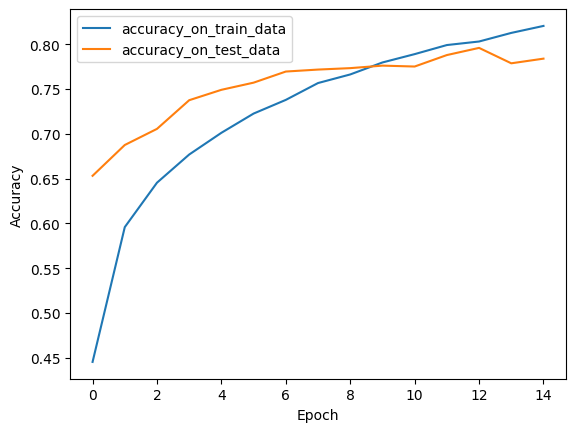

In [ ]:
#Evaluate Model (Trainig Data)
plt.plot(history_5.history['accuracy'],label='accuracy_on_train_data')
plt.plot(history_5.history['val_accuracy'],label='accuracy_on_test_data')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

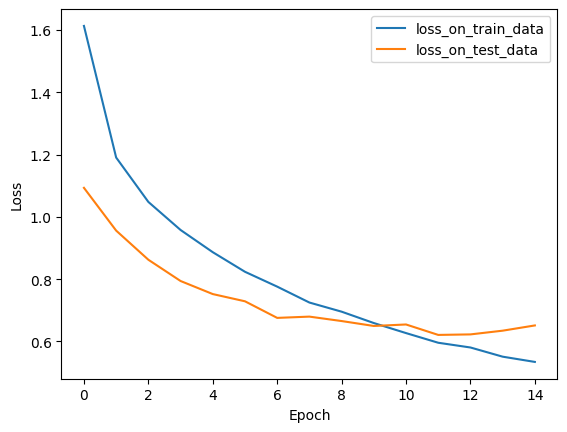

In [ ]:
#Evaluate Model (Test Data)
plt.plot(history_5.history['loss'],label='loss_on_train_data')
plt.plot(history_5.history['val_loss'],label='loss_on_test_data')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()